In [4]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
from envs import *
from policies import *
from data_processors import *
from scipy.stats import sem, t
import os


# font = {'size'   : 13}
# plt.rc('font', **font)  # pass in the font dict as kwargs

# GAPS
# font = {'size'   : 20}
# plt.rc('font', **font)  # pass in the font dict as kwargs



c:\Users\Sara\Miniconda3\envs\learnRlEnv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

def load_costs(base_path, n_exp):
    trial_costs = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_costs.append(data["cost"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_costs)  # Converte in array per calcoli successivi

In [39]:
paths = [
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\RETRAIN_0.1_06_03-00_38_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\RETRAIN_0.2_06_03-01_45_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\RETRAIN_0.3_06_03-02_50_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\RETRAIN_0.4_06_03-03_56_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\RETRAIN_0.5_06_03-05_10_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00"
]
# Labels per i trial
lab = [
    " friction 0.1",
    " friction 0.2",
    " friction 0.3",
    " friction 0.4",
    " friction 0.5",
]

In [40]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

<Figure size 640x480 with 0 Axes>

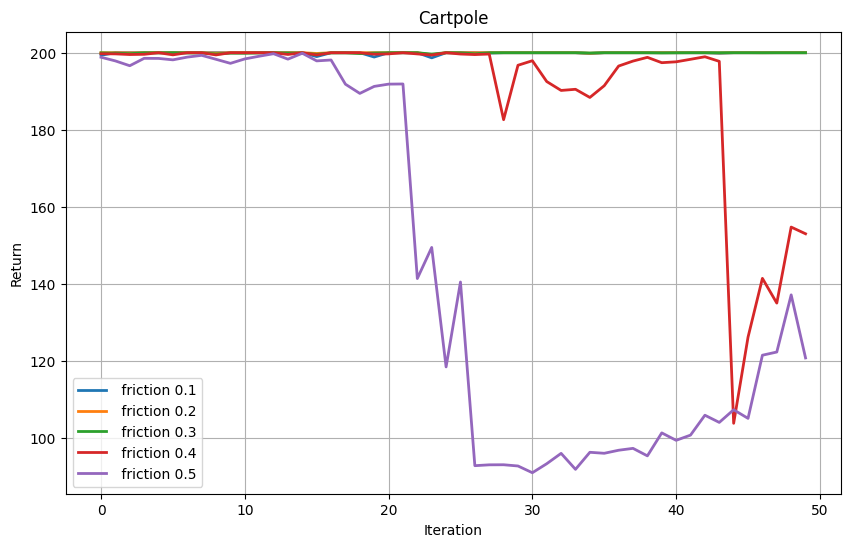

In [44]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance[:50], linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        # lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        # higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        # plt.fill_between(
        #     range(len(mean_performance)),
        #     lower,
        #     higher,
        #     alpha=0.2
        # )

        # print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

In [45]:
# Lista per memorizzare le performance per ogni set
all_costs = []

for path in paths:
    costs = load_costs(path, n_exp=10)
    if costs.size > 0:
        all_costs.append(costs)



 Mean cost of  friction 0.1 :-7.691771754830397
 std cost of  friction 0.1 : 6.947589027406393
 Mean cost of  friction 0.2 :-11.050130450262289
 std cost of  friction 0.2 : 12.893058145750288
 Mean cost of  friction 0.3 :-17.469608453177617
 std cost of  friction 0.3 : 16.96702091994222
 Mean cost of  friction 0.4 :-30.251943292510187
 std cost of  friction 0.4 : 29.923978125608816
 Mean cost of  friction 0.5 :-70.19578339350278
 std cost of  friction 0.5 : 44.47268979001931


<Figure size 640x480 with 0 Axes>

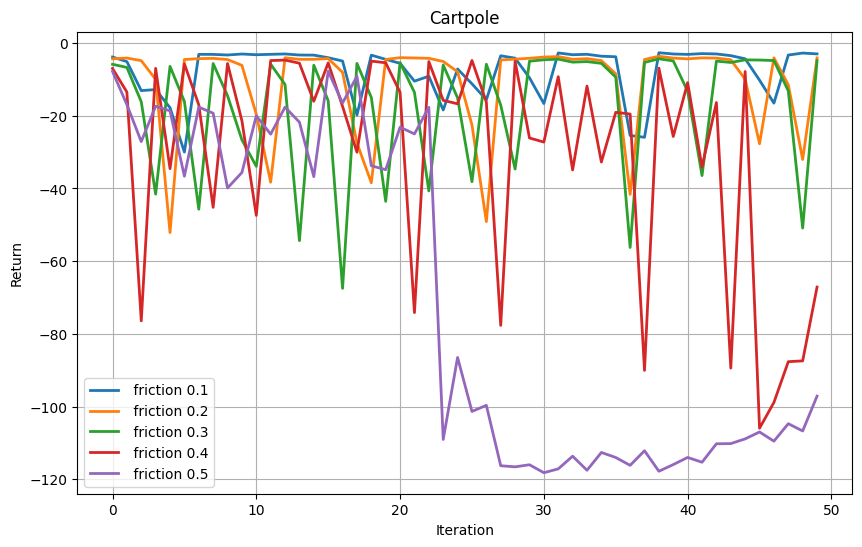

In [47]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, costs in enumerate(all_costs):
    if costs.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_cost = np.mean(costs, axis=0)
        std_cost = np.std(costs, axis=0)

        # Plot della curva media
        plt.plot(mean_cost[:50], linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        #lower = mean_cost-(std_cost)*1.96/np.sqrt(costs.shape[0])
        #higher = mean_cost+(std_cost)*1.96/np.sqrt(costs.shape[0])

        #plt.fill_between(
        #    range(len(mean_cost)),
        #    lower,
        #    higher,
        #    alpha=0.2
        #)

        print(f" Mean cost of {lab[i]} :{np.mean(mean_cost[:50])}")
        print(f" std cost of {lab[i]} : {np.std(mean_cost[:50])}")
        #print(np.mean(lower))
        #print(np.mean(higher))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()